# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadFaizan0023/FlyRank_ML_internship_repo/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My rule and its reason codes

*Write the rule in plain words first. Then the reason codes it can output.*

 **My Rule:**<br> IF gsc_clicks in 2026-03-01 is < gsc_clicks in 2026-04-30 then OR IF gsc_impressions in 2026-03-01 is < gsc_impressions in 2026-04-30 OR IF gsc_avg_position in 2026-03-01 is < gsc_avg_position in 2026-04-30 OR IF ga4_sessions/ga4_users ratio in 2026-03-01 is < ga4_sessions/ga4_users in 2026-04-30 OR IF ctr in 2026-03-01 is < ctr in 2026-04-30 OR IF cpc * gsc_clicks in 2026-03-01 is < cpc * gsc_clicks in 2026-04-30 OR IF sessions_organic in 2026-03-01 is < sessions_organic in 2026-04-30<br> THEN output decline_score accordingly- if one condition met score =1, and the more the conditions met score+=1

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("""
Reason codes:
- low_ctr_and_stale — CTR is low, position is 10+, and content hasn't been updated in a long time
- low_engagement_and_low_scroll — engagement rate and scroll rate are both low, position is 10+
- all_signals_weak — CTR, engagement, and scroll are all low, position is 10+, and content is stale (the full match on your rule)
- stable — none of the above conditions are met, no refresh needed
""")


Reason codes:
- low_ctr_and_stale — CTR is low, position is 10+, and content hasn't been updated in a long time
- low_engagement_and_low_scroll — engagement rate and scroll rate are both low, position is 10+
- all_signals_weak — CTR, engagement, and scroll are all low, position is 10+, and content is stale (the full match on your rule)
- stable — none of the above conditions are met, no refresh needed



In [ ]:
final_training_window = con.sql(f"""
WITH base AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,
        f.report_date,
        f.gsc_clicks,
        f.gsc_impressions,
        f.gsc_avg_position,
        f.ga4_sessions,
        f.ga4_users,
        f.sessions_organic,
        COALESCE(d.cpc, 0)::INT * f.gsc_clicks AS total_cost_per_click,
        d.content_type, d.main_intent, d.cpc, d.search_volume,
        d.competition_level, d.backlinks, d.word_count, d.last_optimized_date
        -- add any other dim_content columns you want carried through
    FROM {TABLES['fact_daily']} f
    LEFT JOIN {TABLES['dim_content']} d
        ON f.client_hash_id = d.client_hash_id
        AND f.content_hash_id = d.content_hash_id
    WHERE f.report_date >= '2026-03-01' AND f.report_date <= '2026-05-30'
)

SELECT
    client_hash_id,
    content_hash_id,
    report_date,
    gsc_clicks, gsc_impressions, gsc_avg_position,
    ga4_sessions, ga4_users, sessions_organic, total_cost_per_click,
    content_type, main_intent, cpc, search_volume, competition_level, backlinks, word_count, last_optimized_date,

    SUM(gsc_clicks) OVER w_last30            AS gsc_clicks_last30,
    SUM(gsc_clicks) OVER w_prev30            AS gsc_clicks_prev30,
    SUM(gsc_impressions) OVER w_last30       AS gsc_impressions_last30,
    SUM(gsc_impressions) OVER w_prev30       AS gsc_impressions_prev30,
    AVG(gsc_avg_position) OVER w_last30      AS gsc_avg_position_last30,
    AVG(gsc_avg_position) OVER w_prev30      AS gsc_avg_position_prev30,
    SUM(ga4_sessions) OVER w_last30          AS ga4_sessions_last30,
    SUM(ga4_sessions) OVER w_prev30          AS ga4_sessions_prev30,
    SUM(ga4_users) OVER w_last30             AS ga4_users_last30,
    SUM(ga4_users) OVER w_prev30             AS ga4_users_prev30,
    SUM(sessions_organic) OVER w_last30      AS sessions_organic_last30,
    SUM(sessions_organic) OVER w_prev30      AS sessions_organic_prev30,
    SUM(total_cost_per_click) OVER w_last30  AS total_cost_per_click_last30,
    SUM(total_cost_per_click) OVER w_prev30  AS total_cost_per_click_prev30,

    (SUM(gsc_clicks) OVER w_last30 > SUM(gsc_clicks) OVER w_prev30)::INT AS clicks_greater,
    (SUM(gsc_impressions) OVER w_last30 > SUM(gsc_impressions) OVER w_prev30)::INT AS impressions_greater,
    (AVG(gsc_avg_position) OVER w_last30 > AVG(gsc_avg_position) OVER w_prev30)::INT AS avg_position_greater,

    (SUM(ga4_sessions) OVER w_last30 / NULLIF(SUM(ga4_users) OVER w_last30, 0))
        AS sessions_per_user_last30,
    (SUM(ga4_sessions) OVER w_prev30 / NULLIF(SUM(ga4_users) OVER w_prev30, 0))
        AS sessions_per_user_prev30

FROM base
WINDOW
    w_last30 AS (
        PARTITION BY client_hash_id, content_hash_id
        ORDER BY report_date
        RANGE BETWEEN INTERVAL 29 DAYS PRECEDING AND CURRENT ROW
    ),
    w_prev30 AS (
        PARTITION BY client_hash_id, content_hash_id
        ORDER BY report_date
        RANGE BETWEEN INTERVAL 59 DAYS PRECEDING AND INTERVAL 30 DAYS PRECEDING
    )
""").show()

## 2. Build the ranked queue (writes the CSV)

*Code the score, rank everything, write work/outputs/baseline_action_score.csv.*

###<h2>2.1: Import Libraries</h2>

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import pandas as pd
import os, getpass
import duckdb
import numpy as np

### <h2>2.2: Get data from hugging face Flyrank repo</h2>

In [2]:
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')

dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


### <h2>2.3: Taken sample 90day window data from fact_daily</h2>

In [3]:
clients_last_3m = con.sql(f"""
    SELECT *
    FROM {TABLES['fact_daily']}
    WHERE report_date >= '2026-03-01'
      AND report_date <= '2026-05-30'
      AND client_has_gsc == 'true'
      AND client_has_ga4 == 'true'
      AND gsc_data_available == 'true'
      AND ga4_data_available == 'true'
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Checking length

In [4]:
print(len(clients_last_3m))

1475963


Check columns

In [6]:
clients_last_3m.columns

Index(['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc',
       'client_has_ga4', 'gsc_data_available', 'ga4_data_available',
       'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position',
       'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions',
       'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct',
       'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai',
       'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude',
       'ai_meta', 'ai_other', 'scroll_events', 'month'],
      dtype='object')

Check NULL impressions if any

In [ ]:
clients_last_3m.isna().sum()

### <h2>2.4: Load dim_content table data in pandas dataframe</h2>

In [4]:
dimf_content = con.sql(f"""
    SELECT *
    FROM {TABLES['dim_content']}
""").df()

check null values

In [ ]:
dimf_content.isna().sum()

### <h2>2.5: Combine tables</h2>

In [5]:
combined_data = clients_last_3m.merge(
    dimf_content,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
    )

check length of window

In [11]:
len(clients_last_3m)

1475963

check length of combined table

In [12]:
len(combined_data)

1475963

columns in combined table

In [7]:
combined_data.columns

Index(['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc',
       'client_has_ga4', 'gsc_data_available', 'ga4_data_available',
       'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position',
       'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions',
       'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct',
       'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai',
       'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude',
       'ai_meta', 'ai_other', 'scroll_events', 'month', 'keyword_hash_id',
       'url_hash_id', 'keyword_char_count', 'keyword_token_count',
       'url_char_count', 'content_created_date', 'content_updated_date',
       'content_type', 'search_volume', 'competition', 'competition_level',
       'cpc', 'main_intent', 'backlinks', 'category_count',
       'keyword_created_date', 'provider_used', 'model_used', 'char_count',
       'word_count', 'last_optimized_da

first 10 rows of combined table

In [14]:
combined_data.head(10)

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,2026-03-01,client_65de48885f4ef01b,content_5c80451459c29b4a,True,True,True,True,5,0,27,...,0,2025-05-30,None,gpt-5-mini,<NA>,<NA>,NaT,NaT,True,False
1,2026-03-01,client_65de48885f4ef01b,content_b1f61fc81b28b2d4,True,True,True,True,39,0,221,...,0,NaT,None,gpt-5-mini,8541,1179,NaT,NaT,True,False
2,2026-03-01,client_65de48885f4ef01b,content_e25ea7297a1dffd3,True,True,True,True,179,0,923,...,0,NaT,None,gpt-5-mini,10622,1489,NaT,NaT,True,False
3,2026-03-01,client_65de48885f4ef01b,content_6b0149a80607dac3,True,True,True,True,72,0,554,...,0,NaT,None,gpt-5-mini,8316,1225,NaT,NaT,True,False
4,2026-03-01,client_65de48885f4ef01b,content_62673eea26c31c17,True,True,True,True,3282,1,20243,...,0,NaT,None,gpt-5-mini,8939,1278,NaT,NaT,True,False
5,2026-03-01,client_65de48885f4ef01b,content_872342e050545a12,True,True,True,True,39,0,255,...,0,NaT,None,gpt-5-mini,10155,1397,NaT,NaT,True,False
6,2026-03-01,client_65de48885f4ef01b,content_3c286ded8bd68120,True,True,True,True,88,1,742,...,0,NaT,None,gpt-5-mini,9188,1280,NaT,NaT,True,False
7,2026-03-01,client_65de48885f4ef01b,content_b2108e8fe3360fa6,True,True,True,True,40,1,212,...,0,NaT,None,gpt-5-mini,11435,1589,NaT,NaT,True,False
8,2026-03-01,client_65de48885f4ef01b,content_4c185d1c173cd53d,True,True,True,True,23,0,697,...,0,NaT,None,gpt-5-mini,9379,1223,NaT,NaT,True,False
9,2026-03-01,client_65de48885f4ef01b,content_bd07be40ea0d5f54,True,True,True,True,23,0,126,...,0,NaT,None,gpt-5-mini,10179,1419,NaT,NaT,True,False


In [13]:
##combined_data = combined_data.sort_values("report_date").reset_index(drop=True)

In [ ]:
#combined_data.head(10)

check values of feature 'is_published'

In [15]:
combined_data['is_published'].value_counts()

,count
is_published,
True,1475444
False,519


check values of feature 'is_deleted'

In [16]:
combined_data['is_deleted'].value_counts()

,count
is_deleted,
False,1475645
True,318


delete rows containing 'is_published' == True AND 'is_deleted' == False

In [17]:
len(combined_data)

1475963

In [6]:
combined_data = combined_data[combined_data["is_published"] == True]

In [19]:
len(combined_data)

1475444

In [7]:
combined_data = combined_data[combined_data["is_deleted"] == False]

In [21]:
len(combined_data)

1475444

In [22]:
combined_data.head(10)

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,2026-03-01,client_65de48885f4ef01b,content_5c80451459c29b4a,True,True,True,True,5,0,27,...,0,2025-05-30,None,gpt-5-mini,<NA>,<NA>,NaT,NaT,True,False
1,2026-03-01,client_65de48885f4ef01b,content_b1f61fc81b28b2d4,True,True,True,True,39,0,221,...,0,NaT,None,gpt-5-mini,8541,1179,NaT,NaT,True,False
2,2026-03-01,client_65de48885f4ef01b,content_e25ea7297a1dffd3,True,True,True,True,179,0,923,...,0,NaT,None,gpt-5-mini,10622,1489,NaT,NaT,True,False
3,2026-03-01,client_65de48885f4ef01b,content_6b0149a80607dac3,True,True,True,True,72,0,554,...,0,NaT,None,gpt-5-mini,8316,1225,NaT,NaT,True,False
4,2026-03-01,client_65de48885f4ef01b,content_62673eea26c31c17,True,True,True,True,3282,1,20243,...,0,NaT,None,gpt-5-mini,8939,1278,NaT,NaT,True,False
5,2026-03-01,client_65de48885f4ef01b,content_872342e050545a12,True,True,True,True,39,0,255,...,0,NaT,None,gpt-5-mini,10155,1397,NaT,NaT,True,False
6,2026-03-01,client_65de48885f4ef01b,content_3c286ded8bd68120,True,True,True,True,88,1,742,...,0,NaT,None,gpt-5-mini,9188,1280,NaT,NaT,True,False
7,2026-03-01,client_65de48885f4ef01b,content_b2108e8fe3360fa6,True,True,True,True,40,1,212,...,0,NaT,None,gpt-5-mini,11435,1589,NaT,NaT,True,False
8,2026-03-01,client_65de48885f4ef01b,content_4c185d1c173cd53d,True,True,True,True,23,0,697,...,0,NaT,None,gpt-5-mini,9379,1223,NaT,NaT,True,False
9,2026-03-01,client_65de48885f4ef01b,content_bd07be40ea0d5f54,True,True,True,True,23,0,126,...,0,NaT,None,gpt-5-mini,10179,1419,NaT,NaT,True,False


### <h2>2.6: Drop unnecessary columns in combined table</h2>

In [6]:
combined_data_v2 = combined_data.drop(columns=['client_has_gsc','client_has_ga4', 'gsc_data_available','gsc_sum_position', 'ga4_data_available','ai_chatgpt',
       'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other','keyword_hash_id',
       'url_hash_id', 'keyword_char_count', 'keyword_token_count',
       'url_char_count','content_type', 'search_volume', 'competition', 'competition_level','main_intent', 'category_count',
       'keyword_created_date', 'provider_used', 'model_used', 'char_count', 'month',
       'word_count', 'last_optimized_date', 'optimization_eligible_date', 'is_published', 'is_deleted'])

In [10]:
len(combined_data_v2)

1475444

In [11]:
combined_data_v2.columns

Index(['report_date', 'client_hash_id', 'content_hash_id', 'gsc_impressions',
       'gsc_clicks', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions',
       'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec',
       'sessions_organic', 'sessions_direct', 'sessions_referral',
       'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events',
       'content_created_date', 'content_updated_date', 'cpc', 'backlinks'],
      dtype='object')

In [26]:
combined_data_v2['report_date'].max()

Timestamp('2026-05-30 00:00:00')

In [27]:
combined_data_v2['report_date'].min()

Timestamp('2026-03-01 00:00:00')

###<h2>2.7: Time split into training and testing window</h2>

In [7]:
combined_data_v2["report_date"] = pd.to_datetime(combined_data_v2["report_date"])

training_window_01 = combined_data_v2[
    (combined_data_v2["report_date"] >= "2026-03-01") & (combined_data_v2["report_date"] <= "2026-03-31")
]
training_window_02 = combined_data_v2[
    (combined_data_v2["report_date"] >= "2026-04-01") & (combined_data_v2["report_date"] <= "2026-04-30")
]
testing_window = combined_data_v2[
    (combined_data_v2["report_date"] >= "2026-05-01") & (combined_data_v2["report_date"] <= "2026-05-31")
]

2.7.1: Working on training window 1

In [47]:
print(training_window_01['report_date'].min())
print(training_window_01['report_date'].max())
print(len(training_window_01))
print(training_window_01.columns)

2026-03-01 00:00:00
2026-03-31 00:00:00
364273
Index(['report_date', 'client_hash_id', 'content_hash_id', 'gsc_impressions',
       'gsc_clicks', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions',
       'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec',
       'sessions_organic', 'sessions_direct', 'sessions_referral',
       'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events',
       'content_created_date', 'content_updated_date', 'cpc', 'backlinks'],
      dtype='object')


In [8]:
reference_date = dimf_content["content_updated_date"].max()
training_window_01["ctr"] = training_window_01["gsc_clicks"] / training_window_01["gsc_impressions"]
training_window_01["engagement_rate"] = training_window_01["ga4_engaged_sessions"] / training_window_01["ga4_sessions"]
training_window_01["scroll_events_rate"] = training_window_01["scroll_events"] / training_window_01["ga4_pageviews"].replace(0, np.nan)
training_window_01["days_since_update"] = (reference_date - training_window_01["content_updated_date"]).dt.days

/tmp/ipykernel_44298/748939243.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_window_01["ctr"] = training_window_01["gsc_clicks"] / training_window_01["gsc_impressions"]
/tmp/ipykernel_44298/748939243.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_window_01["engagement_rate"] = training_window_01["ga4_engaged_sessions"] / training_window_01["ga4_sessions"]
/tmp/ipykernel_44298/748939243.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

In [15]:
print(training_window_01.columns)

Index(['report_date', 'client_hash_id', 'content_hash_id', 'gsc_impressions',
       'gsc_clicks', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions',
       'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec',
       'sessions_organic', 'sessions_direct', 'sessions_referral',
       'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events',
       'content_created_date', 'content_updated_date', 'cpc', 'backlinks',
       'ctr', 'engagement_rate', 'scroll_events_rate', 'days_since_update'],
      dtype='object')


In [16]:
training_window_01.shape

(364273, 26)

In [9]:
training_window_01 = training_window_01.rename(columns={"gsc_impressions": "gsc_impressions_prev30d", "gsc_clicks": "gsc_clicks_prev30d",
                                                        "gsc_avg_position":"gsc_avg_position_prev30d","ga4_pageviews":"ga4_pageviews_prev30d",
                                                        "ga4_sessions":"ga4_sessions_prev30d", "ga4_users":"ga4_users_prev30d",
                                                        "ga4_engaged_sessions":"'ga4_engaged_session_prev30", "ga4_total_engagement_sec":"ga4_total_engagement_sec_prev30",
                                                        "sessions_organic":"sessions_organic_prev30", "sessions_direct":"sessions_direct_prev30",
                                                        "sessions_referral":"sessions_referral_prev30", "sessions_social":"sessions_social_prev30",
                                                        "sessions_paid":"sessions_paid_prev30","sessions_ai":"sessions_ai_prev30",
                                                        "scroll_events":"scroll_events_prev30","cpc":"cpc_prev30", "backlinks":"backlinks_prev30",
                                                        "ctr":"ctr_prev30", "engagement_rate":"engagement_rate_prev30", "scroll_events_rate":"scroll_events_rate_prev30",
                                                        "days_since_update":"days_since_update_prev30"})
print(training_window_01.columns)

Index(['report_date', 'client_hash_id', 'content_hash_id',
       'gsc_impressions_prev30d', 'gsc_clicks_prev30d',
       'gsc_avg_position_prev30d', 'ga4_pageviews_prev30d',
       'ga4_sessions_prev30d', 'ga4_users_prev30d',
       ''ga4_engaged_session_prev30', 'ga4_total_engagement_sec_prev30',
       'sessions_organic_prev30', 'sessions_direct_prev30',
       'sessions_referral_prev30', 'sessions_social_prev30',
       'sessions_paid_prev30', 'sessions_ai_prev30', 'scroll_events_prev30',
       'content_created_date', 'content_updated_date', 'cpc_prev30',
       'backlinks_prev30', 'ctr_prev30', 'engagement_rate_prev30',
       'scroll_events_rate_prev30', 'days_since_update_prev30'],
      dtype='object')


2.7.2: working on training window 2

In [18]:
print(training_window_02['report_date'].min())
print(training_window_02['report_date'].max())
print(len(training_window_02))
print(training_window_02.columns)

2026-04-01 00:00:00
2026-04-30 00:00:00
462246
Index(['report_date', 'client_hash_id', 'content_hash_id', 'gsc_impressions',
       'gsc_clicks', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions',
       'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec',
       'sessions_organic', 'sessions_direct', 'sessions_referral',
       'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events',
       'content_created_date', 'content_updated_date', 'cpc', 'backlinks'],
      dtype='object')


In [10]:
reference_date = dimf_content["content_updated_date"].max()
training_window_02["ctr"] = training_window_02["gsc_clicks"] / training_window_02["gsc_impressions"]
training_window_02["engagement_rate"] = training_window_02["ga4_engaged_sessions"] / training_window_02["ga4_sessions"]
training_window_02["scroll_events_rate"] = training_window_02["scroll_events"] / training_window_02["ga4_pageviews"].replace(0, np.nan)
training_window_02["days_since_update"] = (reference_date - training_window_02["content_updated_date"]).dt.days

/tmp/ipykernel_44298/3260144165.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_window_02["ctr"] = training_window_02["gsc_clicks"] / training_window_02["gsc_impressions"]
/tmp/ipykernel_44298/3260144165.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_window_02["engagement_rate"] = training_window_02["ga4_engaged_sessions"] / training_window_02["ga4_sessions"]
/tmp/ipykernel_44298/3260144165.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

In [11]:
training_window_02 = training_window_02.rename(columns={"gsc_impressions": "gsc_impressions_last30d", "gsc_clicks": "gsc_clicks_last30d",
                                                        "gsc_avg_position":"gsc_avg_position_last30d","ga4_pageviews":"ga4_pageviews_last30d",
                                                        "ga4_sessions":"ga4_sessions_last30d", "ga4_users":"ga4_users_last30d",
                                                        "ga4_engaged_sessions":"'ga4_engaged_session_last30", "ga4_total_engagement_sec":"ga4_total_engagement_sec_last30",
                                                        "sessions_organic":"sessions_organic_last30", "sessions_direct":"sessions_direct_last30",
                                                        "sessions_referral":"sessions_referral_last30", "sessions_social":"sessions_social_last30",
                                                        "sessions_paid":"sessions_paid_last30","sessions_ai":"sessions_ai_last30",
                                                        "scroll_events":"scroll_events_last30","cpc":"cpc_last30", "backlinks":"backlinks_last30",
                                                        "ctr":"ctr_last30", "engagement_rate":"engagement_rate_last30", "scroll_events_rate":"scroll_events_rate_last30",
                                                        "days_since_update":"days_since_update_last30"})
print(training_window_02.columns)

Index(['report_date', 'client_hash_id', 'content_hash_id',
       'gsc_impressions_last30d', 'gsc_clicks_last30d',
       'gsc_avg_position_last30d', 'ga4_pageviews_last30d',
       'ga4_sessions_last30d', 'ga4_users_last30d',
       ''ga4_engaged_session_last30', 'ga4_total_engagement_sec_last30',
       'sessions_organic_last30', 'sessions_direct_last30',
       'sessions_referral_last30', 'sessions_social_last30',
       'sessions_paid_last30', 'sessions_ai_last30', 'scroll_events_last30',
       'content_created_date', 'content_updated_date', 'cpc_last30',
       'backlinks_last30', 'ctr_last30', 'engagement_rate_last30',
       'scroll_events_rate_last30', 'days_since_update_last30'],
      dtype='object')


2.7.3: view testing window details

In [55]:
print(testing_window['report_date'].min())
print(testing_window['report_date'].max())
print(len(testing_window))
print(testing_window.columns)

2026-05-01 00:00:00
2026-05-30 00:00:00
648925
Index(['report_date', 'client_hash_id', 'content_hash_id', 'gsc_impressions',
       'gsc_clicks', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions',
       'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec',
       'sessions_organic', 'sessions_direct', 'sessions_referral',
       'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events',
       'content_created_date', 'content_updated_date', 'cpc', 'backlinks'],
      dtype='object')


### <h2>2.8: Feature engineering</h2>

2.8.1: Merge training window 1 and 2

In [12]:
features_column = training_window_01.merge(
    training_window_02,
    on=("client_hash_id", "content_hash_id", "content_created_date", "content_updated_date"),
    how="inner"
)

In [18]:
features_column.columns

Index(['report_date_x', 'client_hash_id', 'content_hash_id',
       'gsc_impressions_prev30d', 'gsc_clicks_prev30d',
       'gsc_avg_position_prev30d', 'ga4_pageviews_prev30d',
       'ga4_sessions_prev30d', 'ga4_users_prev30d',
       ''ga4_engaged_session_prev30', 'ga4_total_engagement_sec_prev30',
       'sessions_organic_prev30', 'sessions_direct_prev30',
       'sessions_referral_prev30', 'sessions_social_prev30',
       'sessions_paid_prev30', 'sessions_ai_prev30', 'scroll_events_prev30',
       'content_created_date', 'content_updated_date', 'cpc_prev30',
       'backlinks_prev30', 'ctr_prev30', 'engagement_rate_prev30',
       'scroll_events_rate_prev30', 'days_since_update_prev30',
       'report_date_y', 'gsc_impressions_last30d', 'gsc_clicks_last30d',
       'gsc_avg_position_last30d', 'ga4_pageviews_last30d',
       'ga4_sessions_last30d', 'ga4_users_last30d',
       ''ga4_engaged_session_last30', 'ga4_total_engagement_sec_last30',
       'sessions_organic_last30', 'session

In [42]:
features_column.head(10)

,report_date_x,client_hash_id,content_hash_id,gsc_impressions_prev30d,gsc_clicks_prev30d,gsc_avg_position_prev30d,ga4_pageviews_prev30d,ga4_sessions_prev30d,ga4_users_prev30d,'ga4_engaged_session_prev30,...,sessions_social_last30,sessions_paid_last30,sessions_ai_last30,scroll_events_last30,cpc_last30,backlinks_last30,ctr_last30,engagement_rate_last30,scroll_events_rate_last30,days_since_update_last30
0,2026-03-01,client_65de48885f4ef01b,content_b1f61fc81b28b2d4,39,0,5.666667,2,2,1,0,...,0,0,0,0,NaN,<NA>,0.000000,0.000000,0.0,131
1,2026-03-01,client_65de48885f4ef01b,content_b1f61fc81b28b2d4,39,0,5.666667,2,2,1,0,...,0,0,0,0,NaN,<NA>,0.000000,0.000000,0.0,131
2,2026-03-01,client_65de48885f4ef01b,content_b1f61fc81b28b2d4,39,0,5.666667,2,2,1,0,...,0,0,0,0,NaN,<NA>,0.029412,0.000000,0.0,131
3,2026-03-01,client_65de48885f4ef01b,content_b1f61fc81b28b2d4,39,0,5.666667,2,2,1,0,...,0,0,0,0,NaN,<NA>,0.034483,0.000000,0.0,131
4,2026-03-01,client_65de48885f4ef01b,content_b1f61fc81b28b2d4,39,0,5.666667,2,2,1,0,...,0,0,0,0,NaN,<NA>,0.000000,0.000000,0.0,131
5,2026-03-01,client_65de48885f4ef01b,content_b1f61fc81b28b2d4,39,0,5.666667,2,2,1,0,...,0,0,0,1,NaN,<NA>,0.000000,0.500000,0.5,131
6,2026-03-01,client_65de48885f4ef01b,content_b1f61fc81b28b2d4,39,0,5.666667,2,2,1,0,...,0,0,0,3,NaN,<NA>,0.088235,0.333333,1.0,131
7,2026-03-01,client_65de48885f4ef01b,content_e25ea7297a1dffd3,179,0,5.156425,2,2,2,0,...,0,0,0,0,NaN,<NA>,0.000000,0.000000,0.0,131
8,2026-03-01,client_65de48885f4ef01b,content_e25ea7297a1dffd3,179,0,5.156425,2,2,2,0,...,0,0,0,0,NaN,<NA>,0.011236,0.000000,0.0,131
9,2026-03-01,client_65de48885f4ef01b,content_e25ea7297a1dffd3,179,0,5.156425,2,2,2,0,...,0,0,0,0,NaN,<NA>,0.013889,0.000000,0.0,131


2.8.2: View details of features_column table

In [41]:
features_column["ctr_last30"].describe()

,ctr_last30
count,4.171245e+06
mean,7.890682e-03
std,2.140307e-02
min,0.000000e+00
25%,0.000000e+00
50%,3.525264e-03
75%,9.523810e-03
max,1.000000e+00


In [42]:
print(features_column["engagement_rate_last30"].describe())
features_column["engagement_rate_prev30"].describe()

count    4.138671e+06
mean     4.658785e-02
std      1.736522e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: engagement_rate_last30, dtype: float64


,engagement_rate_prev30
count,4.141952e+06
mean,4.002258e-02
std,1.576458e-01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,1.000000e+00


In [24]:
print(features_column["scroll_events_rate_prev30"].describe())
print(features_column["scroll_events_rate_last30"].describe())

count    4.167744e+06
mean     1.302859e-01
std      2.605904e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.428571e-01
max      3.000000e+00
Name: scroll_events_rate_prev30, dtype: float64
count    4.169554e+06
mean     9.558735e-02
std      2.332455e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.000000e+00
Name: scroll_events_rate_last30, dtype: float64


In [43]:
print(features_column["days_since_update_prev30"].describe())
print(features_column["days_since_update_last30"].describe())

count    4.171245e+06
mean     3.766242e+01
std      3.933741e+01
min      0.000000e+00
25%      1.400000e+01
50%      2.500000e+01
75%      4.700000e+01
max      3.610000e+02
Name: days_since_update_prev30, dtype: float64
count    4.171245e+06
mean     3.766242e+01
std      3.933741e+01
min      0.000000e+00
25%      1.400000e+01
50%      2.500000e+01
75%      4.700000e+01
max      3.610000e+02
Name: days_since_update_last30, dtype: float64


2.8.3: final feature set

In [19]:
features_column.columns

Index(['report_date_x', 'client_hash_id', 'content_hash_id',
       'gsc_impressions_prev30d', 'gsc_clicks_prev30d',
       'gsc_avg_position_prev30d', 'ga4_pageviews_prev30d',
       'ga4_sessions_prev30d', 'ga4_users_prev30d',
       ''ga4_engaged_session_prev30', 'ga4_total_engagement_sec_prev30',
       'sessions_organic_prev30', 'sessions_direct_prev30',
       'sessions_referral_prev30', 'sessions_social_prev30',
       'sessions_paid_prev30', 'sessions_ai_prev30', 'scroll_events_prev30',
       'content_created_date', 'content_updated_date', 'cpc_prev30',
       'backlinks_prev30', 'ctr_prev30', 'engagement_rate_prev30',
       'scroll_events_rate_prev30', 'days_since_update_prev30',
       'report_date_y', 'gsc_impressions_last30d', 'gsc_clicks_last30d',
       'gsc_avg_position_last30d', 'ga4_pageviews_last30d',
       'ga4_sessions_last30d', 'ga4_users_last30d',
       ''ga4_engaged_session_last30', 'ga4_total_engagement_sec_last30',
       'sessions_organic_last30', 'session

In [13]:
features_column["decline_score"] = (
    (features_column["ctr_last30"] < features_column["ctr_prev30"]).astype(int) +
    (features_column["engagement_rate_last30"] <= features_column["engagement_rate_prev30"]).astype(int) +
    (features_column["scroll_events_rate_last30"] <= features_column["scroll_events_rate_prev30"]).astype(int) +
    (features_column["gsc_avg_position_last30d"] >= features_column["gsc_avg_position_prev30d"]).astype(int) +
    (features_column["gsc_impressions_last30d"] <= features_column["gsc_impressions_prev30d"]).astype(int) +
    (features_column["gsc_clicks_last30d"] <= features_column["gsc_clicks_prev30d"]).astype(int) +
    (features_column["ga4_pageviews_last30d"] <= features_column["ga4_pageviews_prev30d"]).astype(int) +
    (features_column["ga4_users_last30d"] <= features_column["ga4_users_prev30d"]).astype(int)+
    (features_column["ga4_total_engagement_sec_last30"] <= features_column["ga4_total_engagement_sec_prev30"]).astype(int) +
    (features_column["sessions_organic_last30"] <= features_column["sessions_organic_prev30"]).astype(int) +
    (features_column["sessions_direct_last30"] <= features_column["sessions_direct_prev30"]).astype(int) +
    (features_column["sessions_referral_last30"] <= features_column["sessions_referral_prev30"]).astype(int) +
    (features_column["sessions_social_last30"] <= features_column["sessions_social_prev30"]).astype(int) +
    (features_column["sessions_paid_last30"] <= features_column["sessions_paid_prev30"]).astype(int) +
    (features_column["sessions_ai_last30"] <= features_column["sessions_ai_prev30"]).astype(int) +
    (features_column["scroll_events_last30"] <= features_column["scroll_events_prev30"]).astype(int) +
    (features_column["cpc_last30"] <= features_column["cpc_prev30"]).astype(int)
)

In [27]:
features_column['decline_score'].value_counts()

,count
decline_score,
15,720258
16,649399
14,643912
13,573035
12,450857
11,349304
10,234936
17,212004
9,135768


In [14]:
final_features_set = features_column.drop(columns=["report_date_x", "report_date_y"])

### <h2>2.9: 2 Signals: <br>  
1. CTR-vs-position (FlyRank signal)<br>
2. GA4 sessions vs GSC clicks </h2>

In [17]:
final_features_set.columns

Index(['client_hash_id', 'content_hash_id', 'gsc_impressions_prev30d',
       'gsc_clicks_prev30d', 'gsc_avg_position_prev30d',
       'ga4_pageviews_prev30d', 'ga4_sessions_prev30d', 'ga4_users_prev30d',
       ''ga4_engaged_session_prev30', 'ga4_total_engagement_sec_prev30',
       'sessions_organic_prev30', 'sessions_direct_prev30',
       'sessions_referral_prev30', 'sessions_social_prev30',
       'sessions_paid_prev30', 'sessions_ai_prev30', 'scroll_events_prev30',
       'content_created_date', 'content_updated_date', 'cpc_prev30',
       'backlinks_prev30', 'ctr_prev30', 'engagement_rate_prev30',
       'scroll_events_rate_prev30', 'days_since_update_prev30',
       'gsc_impressions_last30d', 'gsc_clicks_last30d',
       'gsc_avg_position_last30d', 'ga4_pageviews_last30d',
       'ga4_sessions_last30d', 'ga4_users_last30d',
       ''ga4_engaged_session_last30', 'ga4_total_engagement_sec_last30',
       'sessions_organic_last30', 'sessions_direct_last30',
       'sessions_referr

2.9.1 Signal 1: CTR vs. GSC Average Position (Residual Analysis)
We examine how much CTR deviates from the expected trend based on ranking position.

Signal 1 Correlation (Prev 30d): -0.1428
Signal 1 Correlation (Last 30d): -0.0984


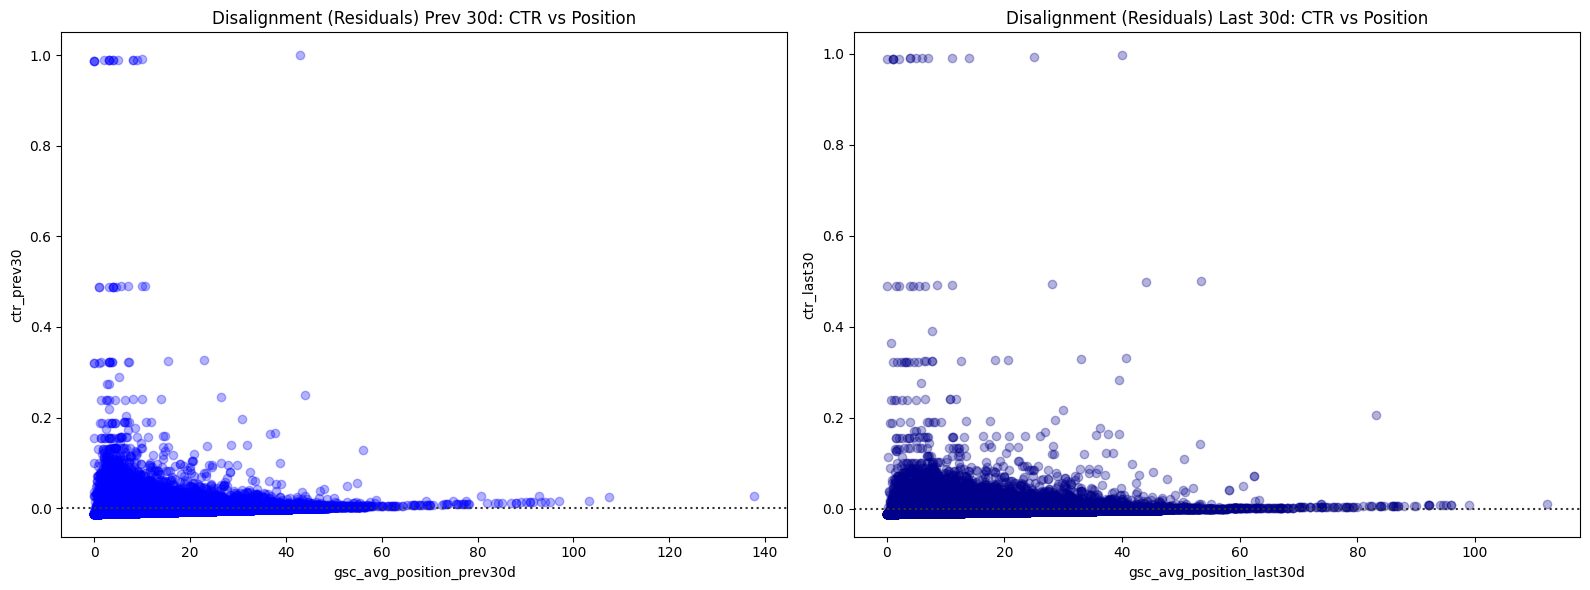

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out NaN/Inf for correlation calculation
s1_data = final_features_set.dropna(subset=['ctr_prev30', 'gsc_avg_position_prev30d', 'ctr_last30', 'gsc_avg_position_last30d'])
s1_sample = s1_data.sample(min(50000, len(s1_data)))

# Scores
print(f"Signal 1 Correlation (Prev 30d): {s1_data['ctr_prev30'].corr(s1_data['gsc_avg_position_prev30d']):.4f}")
print(f"Signal 1 Correlation (Last 30d): {s1_data['ctr_last30'].corr(s1_data['gsc_avg_position_last30d']):.4f}")

# Residual Plot to show disalignment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.residplot(x='gsc_avg_position_prev30d', y='ctr_prev30', data=s1_sample, ax=ax1, color='blue', scatter_kws={'alpha':0.3})
ax1.set_title('Disalignment (Residuals) Prev 30d: CTR vs Position')

sns.residplot(x='gsc_avg_position_last30d', y='ctr_last30', data=s1_sample, ax=ax2, color='darkblue', scatter_kws={'alpha':0.3})
ax2.set_title('Disalignment (Residuals) Last 30d: CTR vs Position')

plt.tight_layout()
plt.show()

2.9.2 Signal 2: GA4 Sessions vs. GSC Clicks (Residual Analysis)
This plot reveals which pages are 'outliers'—receiving sessions without clicks or clicks without sessions.

Signal 2 Correlation (Prev 30d): 0.3021
Signal 2 Correlation (Last 30d): 0.2381


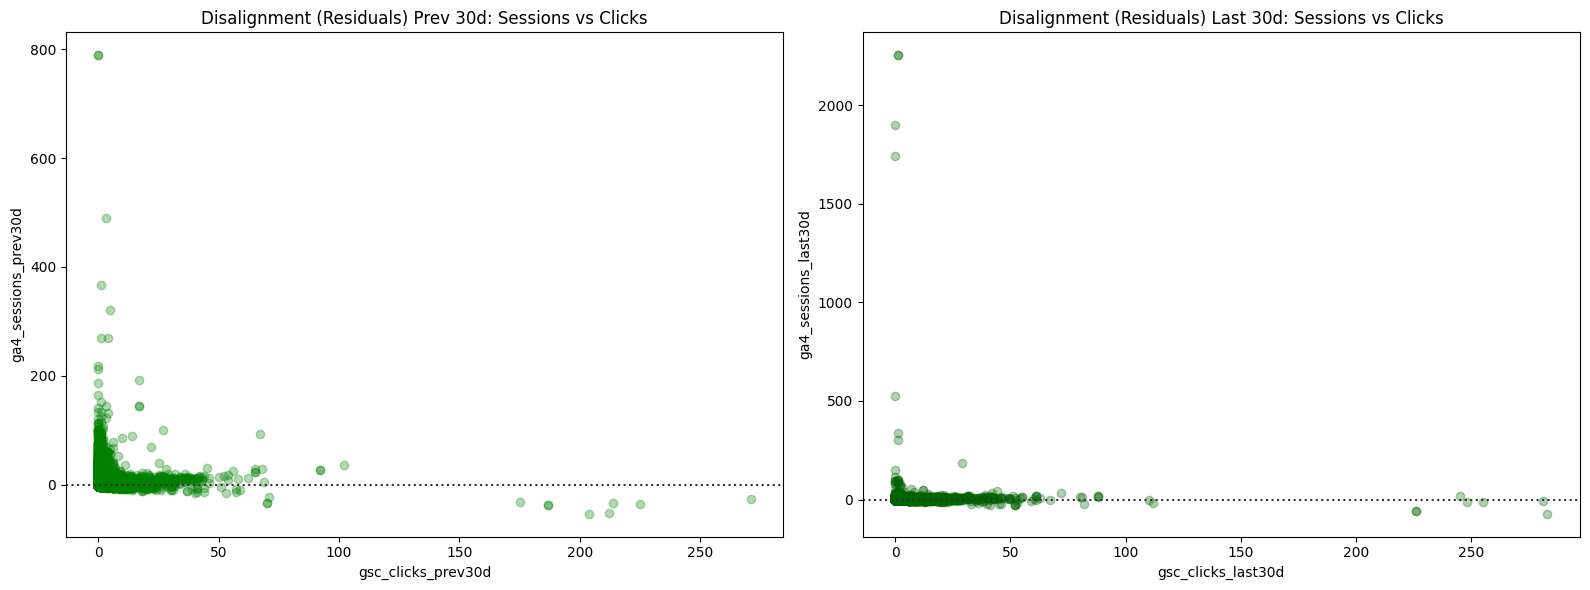

In [16]:
# Filter out NaN/Inf for correlation calculation
s2_data = final_features_set.dropna(subset=['ga4_sessions_prev30d', 'gsc_clicks_prev30d', 'ga4_sessions_last30d', 'gsc_clicks_last30d'])
s2_sample = s2_data.sample(min(50000, len(s2_data)))

# Scores
print(f"Signal 2 Correlation (Prev 30d): {s2_data['ga4_sessions_prev30d'].corr(s2_data['gsc_clicks_prev30d']):.4f}")
print(f"Signal 2 Correlation (Last 30d): {s2_data['ga4_sessions_last30d'].corr(s2_data['gsc_clicks_last30d']):.4f}")

# Residual Plot to show disalignment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.residplot(x='gsc_clicks_prev30d', y='ga4_sessions_prev30d', data=s2_sample, ax=ax1, color='green', scatter_kws={'alpha':0.3})
ax1.set_title('Disalignment (Residuals) Prev 30d: Sessions vs Clicks')

sns.residplot(x='gsc_clicks_last30d', y='ga4_sessions_last30d', data=s2_sample, ax=ax2, color='darkgreen', scatter_kws={'alpha':0.3})
ax2.set_title('Disalignment (Residuals) Last 30d: Sessions vs Clicks')

plt.tight_layout()
plt.show()

**Observed and calculated Conclusion on sample '50000' values**<br>

**Signal 1:** CTR and position does not correlate much with each other and due to slightly negative correlation values these are related slightly negative. And if we look at the plots the CTR is near to 0 when avg_position is good and less than 10, thats make these two signals not much correlating with each other.

**Signal 2:** The correlation between clicks and session is also near to 0 means no correlation somehow between them. If we look at the plot, when clicks are near to 0 then sessions are also near to 0 - and these values are too much from a sample that we took. WHen clicks are greater then we do not find any session there as per graph above. So, no relation with each other much


2.9.3: Sort decline_score proxy label in descending order for data window

In [17]:
ranked_queue = final_features_set.sort_values("decline_score", ascending=False)

2.9.4: Print top 10 ranked rows

In [20]:
print("Top 10")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
display(ranked_queue[:10])

Top 10


,client_hash_id,content_hash_id,gsc_impressions_prev30d,gsc_clicks_prev30d,gsc_avg_position_prev30d,ga4_pageviews_prev30d,ga4_sessions_prev30d,ga4_users_prev30d,'ga4_engaged_session_prev30,ga4_total_engagement_sec_prev30,sessions_organic_prev30,sessions_direct_prev30,sessions_referral_prev30,sessions_social_prev30,sessions_paid_prev30,sessions_ai_prev30,scroll_events_prev30,content_created_date,content_updated_date,cpc_prev30,backlinks_prev30,ctr_prev30,engagement_rate_prev30,scroll_events_rate_prev30,days_since_update_prev30,gsc_impressions_last30d,gsc_clicks_last30d,gsc_avg_position_last30d,ga4_pageviews_last30d,ga4_sessions_last30d,ga4_users_last30d,'ga4_engaged_session_last30,ga4_total_engagement_sec_last30,sessions_organic_last30,sessions_direct_last30,sessions_referral_last30,sessions_social_last30,sessions_paid_last30,sessions_ai_last30,scroll_events_last30,cpc_last30,backlinks_last30,ctr_last30,engagement_rate_last30,scroll_events_rate_last30,days_since_update_last30,decline_score
861389,client_e5c2aa26a8598242,content_ffcbdf209cae5abc,214,3,3.962617,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-18,0.00,0,0.014019,0.0,0.0,18,193,1,16.383420,2,2,2,0,0,1,0,0,0,0,0,0,0.00,0,0.005181,0.0,0.0,18,17
861388,client_e5c2aa26a8598242,content_ffcbdf209cae5abc,214,3,3.962617,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-18,0.00,0,0.014019,0.0,0.0,18,192,1,27.437500,2,2,1,0,0,2,0,0,0,0,0,0,0.00,0,0.005208,0.0,0.0,18,17
861387,client_e5c2aa26a8598242,content_ffcbdf209cae5abc,214,3,3.962617,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-18,0.00,0,0.014019,0.0,0.0,18,187,0,20.625668,1,1,1,0,0,0,0,0,0,0,0,0,0.00,0,0.000000,0.0,0.0,18,17
861494,client_e5c2aa26a8598242,content_9f49580281520710,83,3,1.951807,4,4,4,0,0,4,0,0,0,0,0,0,2026-02-18,2026-06-22,0.00,0,0.036145,0.0,0.0,14,56,1,11.517857,2,2,2,0,0,2,0,0,0,0,0,0,0.00,0,0.017857,0.0,0.0,14,17
861493,client_e5c2aa26a8598242,content_9f49580281520710,83,3,1.951807,4,4,4,0,0,4,0,0,0,0,0,0,2026-02-18,2026-06-22,0.00,0,0.036145,0.0,0.0,14,56,0,8.000000,1,1,1,0,0,1,0,0,0,0,0,0,0.00,0,0.000000,0.0,0.0,14,17
861385,client_e5c2aa26a8598242,content_ffcbdf209cae5abc,214,3,3.962617,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-18,0.00,0,0.014019,0.0,0.0,18,177,0,27.819209,2,2,2,0,0,0,0,0,0,0,0,0,0.00,0,0.000000,0.0,0.0,18,17
861365,client_e5c2aa26a8598242,content_5e0b5a0c9de5ce66,141,1,3.851064,1,1,1,0,0,1,0,0,0,0,0,0,2026-02-18,2026-06-22,0.05,0,0.007092,0.0,0.0,14,133,0,7.736842,1,1,1,0,0,0,0,0,0,0,0,0,0.05,0,0.000000,0.0,0.0,14,17
861549,client_e5c2aa26a8598242,content_29a2823ec2077049,522,3,0.440613,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-30,1.34,0,0.005747,0.0,0.0,6,456,0,4.765351,1,1,1,0,0,1,0,0,0,0,0,0,1.34,0,0.000000,0.0,0.0,6,17
861547,client_e5c2aa26a8598242,content_29a2823ec2077049,522,3,0.440613,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-30,1.34,0,0.005747,0.0,0.0,6,358,2,5.650838,2,2,2,0,0,2,0,0,0,0,0,0,1.34,0,0.005587,0.0,0.0,6,17
861562,client_e5c2aa26a8598242,content_29a2823ec2077049,522,3,0.440613,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-30,1.34,0,0.005747,0.0,0.0,6,247,1,7.651822,1,1,1,0,0,0,0,0,0,0,0,0,1.34,0,0.004049,0.0,0.0,6,17


2.9.5: Save ranked queue data in 'CSV' format in 'work/outputs' directory and locak machine

In [22]:
from google.colab import files

# Ensure the output directory exists
os.makedirs('work/outputs', exist_ok=True)

# Save the ranked queue to CSV
output_path = 'work/outputs/baseline_action_score.csv'
ranked_queue.to_csv(output_path, index=False)

print(f'File saved to {output_path}')

# Trigger browser download to local machine
#files.download(output_path)

File saved to work/outputs/baseline_action_score.csv. Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. Top-20 review

*For each of the top 20: action, reason code, confidence note, and what would make it wrong.*

<h2>3.1: Top 20</h2>

In [23]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
ranked_queue[:20]

,client_hash_id,content_hash_id,gsc_impressions_prev30d,gsc_clicks_prev30d,gsc_avg_position_prev30d,ga4_pageviews_prev30d,ga4_sessions_prev30d,ga4_users_prev30d,'ga4_engaged_session_prev30,ga4_total_engagement_sec_prev30,sessions_organic_prev30,sessions_direct_prev30,sessions_referral_prev30,sessions_social_prev30,sessions_paid_prev30,sessions_ai_prev30,scroll_events_prev30,content_created_date,content_updated_date,cpc_prev30,backlinks_prev30,ctr_prev30,engagement_rate_prev30,scroll_events_rate_prev30,days_since_update_prev30,gsc_impressions_last30d,gsc_clicks_last30d,gsc_avg_position_last30d,ga4_pageviews_last30d,ga4_sessions_last30d,ga4_users_last30d,'ga4_engaged_session_last30,ga4_total_engagement_sec_last30,sessions_organic_last30,sessions_direct_last30,sessions_referral_last30,sessions_social_last30,sessions_paid_last30,sessions_ai_last30,scroll_events_last30,cpc_last30,backlinks_last30,ctr_last30,engagement_rate_last30,scroll_events_rate_last30,days_since_update_last30,decline_score
861389,client_e5c2aa26a8598242,content_ffcbdf209cae5abc,214,3,3.962617,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-18,0.00,0,0.014019,0.0,0.0,18,193,1,16.383420,2,2,2,0,0,1,0,0,0,0,0,0,0.00,0,0.005181,0.0,0.0,18,17
861388,client_e5c2aa26a8598242,content_ffcbdf209cae5abc,214,3,3.962617,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-18,0.00,0,0.014019,0.0,0.0,18,192,1,27.437500,2,2,1,0,0,2,0,0,0,0,0,0,0.00,0,0.005208,0.0,0.0,18,17
861387,client_e5c2aa26a8598242,content_ffcbdf209cae5abc,214,3,3.962617,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-18,0.00,0,0.014019,0.0,0.0,18,187,0,20.625668,1,1,1,0,0,0,0,0,0,0,0,0,0.00,0,0.000000,0.0,0.0,18,17
861494,client_e5c2aa26a8598242,content_9f49580281520710,83,3,1.951807,4,4,4,0,0,4,0,0,0,0,0,0,2026-02-18,2026-06-22,0.00,0,0.036145,0.0,0.0,14,56,1,11.517857,2,2,2,0,0,2,0,0,0,0,0,0,0.00,0,0.017857,0.0,0.0,14,17
861493,client_e5c2aa26a8598242,content_9f49580281520710,83,3,1.951807,4,4,4,0,0,4,0,0,0,0,0,0,2026-02-18,2026-06-22,0.00,0,0.036145,0.0,0.0,14,56,0,8.000000,1,1,1,0,0,1,0,0,0,0,0,0,0.00,0,0.000000,0.0,0.0,14,17
861385,client_e5c2aa26a8598242,content_ffcbdf209cae5abc,214,3,3.962617,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-18,0.00,0,0.014019,0.0,0.0,18,177,0,27.819209,2,2,2,0,0,0,0,0,0,0,0,0,0.00,0,0.000000,0.0,0.0,18,17
861365,client_e5c2aa26a8598242,content_5e0b5a0c9de5ce66,141,1,3.851064,1,1,1,0,0,1,0,0,0,0,0,0,2026-02-18,2026-06-22,0.05,0,0.007092,0.0,0.0,14,133,0,7.736842,1,1,1,0,0,0,0,0,0,0,0,0,0.05,0,0.000000,0.0,0.0,14,17
861549,client_e5c2aa26a8598242,content_29a2823ec2077049,522,3,0.440613,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-30,1.34,0,0.005747,0.0,0.0,6,456,0,4.765351,1,1,1,0,0,1,0,0,0,0,0,0,1.34,0,0.000000,0.0,0.0,6,17
861547,client_e5c2aa26a8598242,content_29a2823ec2077049,522,3,0.440613,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-30,1.34,0,0.005747,0.0,0.0,6,358,2,5.650838,2,2,2,0,0,2,0,0,0,0,0,0,1.34,0,0.005587,0.0,0.0,6,17
861562,client_e5c2aa26a8598242,content_29a2823ec2077049,522,3,0.440613,3,3,3,0,0,3,0,0,0,0,0,0,2026-02-18,2026-06-30,1.34,0,0.005747,0.0,0.0,6,247,1,7.651822,1,1,1,0,0,0,0,0,0,0,0,0,1.34,0,0.004049,0.0,0.0,6,17


<h2>My Observation</h2>

<h2>3.2: Action: "Refresh_needed" because decline score is highest </h2>

<h2>3.3: Reason code: <br>
All signals weak for all 20 rows</h2>

<h2>3.4: Confidence note:</h2>
1. High confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in 21-100 bucket. The day_since_update is also > 30. And impression is just 1.<br>
2. Medium confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in > 10 bucket. The day_since_update is also > 30. But impressions are somewhat there<br>
3. Medium confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in > 10 bucket. The day_since_update is also > 30. But impressions are somewhat there.<br>
4. High confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in 21-100 bucket. The day_since_update is also > 100. <br>
5. Medium confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in > 10 bucket. The day_since_update is also > 30. But impressions are 54 which are somewhat reasonable for this confidence.<br>
6. Medium confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies around 10 bucket. The day_since_update is also > 30. Because of where it lies in position medium confidence.<br>
7.  Medium confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in > 10 bucket. The day_since_update is also > 30. The confidence is this because impressions are somewhat reasonable. <br>
8. High confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in 21-100 bucket. The day_since_update is also > 30. Impressions are also very less. <br>
9. High confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in 21-100 bucket. The day_since_update is also > 30. Impressions are also very less.<br>
10. Medium confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in 21-100 bucket. The day_since_update is also > 30. Impressions are 67 and so the above 0 values are somewhat problamatic.<br>
11. High confidence: As ctr, engagement rate and scroll_rate are 0 each, and impressions are low as well as position.<br>
12. Medium confidence: As ctr, engagement rate and scroll_rate are 0 each, and avg. position is fine but low impressions.<br>
13. High confidence: As ctr, engagement rate and scroll_rate are 0 each, and impressions are low as well as position.<br>
14. Medium confidence: As ctr, engagement rate and scroll_rate are 0 each, and avg. position is lower but somewhat reasonable impressions.<br>
15. High confidence: As ctr, engagement rate and scroll_rate are 0 each, and impressions are low and position is lower also.<br>
16. High confidence: As ctr, engagement rate and scroll_rate are 0 each, and impressions are low but position is close to 10 but due to other strong factors high confidence.<br>
17. High confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in 11-20 bucket. The day_since_update is also > 100.<br>
18. High confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in 11-20 bucket. The day_since_update is also > 100.<br>
19. High confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in 11-20 bucket. The day_since_update is also > 100.<br>
20. High confidence: As ctr, engagement rate and scroll_rate are 0 each, and position also lies in 11-20 bucket. The day_since_update is also > 100.


<h2>3.5: What would make it wrong?</h2>
1. Would be wrong if this page simply hasn't accumulated enough traffic yet to judge — not a real performance problem.<br>
2. Would be wrong if the page is on the edge of page 1 and just needs time, not a content refresh.<br>
3. Would be wrong if 38 days is too soon to call this "long neglected" — may just be normal maturation lag.<br>
4. Would be wrong if this page's low traffic is due to a niche/low-demand topic rather than declining quality.<br>
5. Would be wrong if this traffic came from a single anomalous spike (e.g., bot traffic or a one-off referral) rather than sustained real visits.<br>
6. Would be wrong if position is measurement noise right at the 10/11 boundary, making the "position ≥ 10" trigger arbitrary here.<br>
7. Would be wrong if 28 impressions with genuinely 0 engagement reflects a mismatched search intent, not something a refresh would fix.<br>
8. Would be wrong if this page is simply new/low-priority and not worth refresh effort yet.<br>
9. Would be wrong if low volume reflects a legitimately low-demand keyword, not decaying content.<br>
10. Would be wrong if impressions are inflated by irrelevant/broad-match queries that were never going to convert regardless of content quality.<br>
11. Would be wrong if this is simply a poor keyword-content match rather than a staleness issue.<br>
12. Would be wrong if the page is too new for its traffic to have stabilized.<br>
13. Would be wrong if low volume reflects niche topic demand, not quality decay.<br>
14. Would be wrong if this page's topic naturally has zero-click search behavior (e.g., answers fully shown in the snippet).<br>
15. Would be wrong if this page gets almost no search demand regardless of freshness.<br>
16. Would be wrong if the ranking position itself is unstable/fluctuating day to day, making this single snapshot misleading.<br>
17. Would be wrong if low impressions reflect seasonal/cyclical demand rather than a real decline.<br>
18. Would be wrong if position (10.4) is borderline enough that this page is essentially performing fine.<br>
19. Would be wrong if this reflects low search demand for the topic, not neglect.<br>
20. Would be wrong if position (10.4) is right at the boundary and effectively equivalent to a "good" ranking.

## 4. Weak picks + leakage check

*Which picks look wrong and why? Confirm no product flags or future windows leaked in.*

<p> Weak picks: 1, 8, 12, 13, 15, 19</p>
<p> Reason: Because impressions are there very few and statistically it would be difficult to predict whether refresh needed or not as ctr, engagement rate, scroll rate will be less as impressions are less or maybe 0, as in this case.</p>

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
weak_picks = ranked_queue[:20].copy()

In [ ]:
weak_picks[weak_picks['gsc_impressions'] < 10]

,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_avg_position,ctr,engagement_rate,scroll_rate,days_since_update,position_bucket,engagement_bucket,decline_score
1475959,2026-05-30,client_1a8bf67cad4ee525,content_5eb9c0b1de0202d2,9,17.444444,0.0,0.0,0.0,35,11-20,NaN,5
1475942,2026-05-30,client_1a8bf67cad4ee525,content_5eb560fef36a11e6,1,11.000000,0.0,0.0,0.0,35,11-20,NaN,5
598710,2026-04-16,client_23a62021009f63c4,content_02f32646ff66bb41,5,20.400000,0.0,0.0,0.0,47,21-100,NaN,5
598725,2026-04-16,client_23a62021009f63c4,content_27aefb596af51514,7,23.142857,0.0,0.0,0.0,47,21-100,NaN,5
598705,2026-04-16,client_23a62021009f63c4,content_5f61d45d72e0b152,5,29.800000,0.0,0.0,0.0,47,21-100,NaN,5
598704,2026-04-16,client_23a62021009f63c4,content_5f5f80f37c39c312,1,19.000000,0.0,0.0,0.0,47,11-20,NaN,5
598700,2026-04-16,client_23a62021009f63c4,content_648be9d432a4eba4,3,65.000000,0.0,0.0,0.0,47,21-100,NaN,5
598697,2026-04-16,client_23a62021009f63c4,content_9dba3c0f79985b7c,5,15.600000,0.0,0.0,0.0,47,11-20,NaN,5
598695,2026-04-16,client_23a62021009f63c4,content_ef6f78ab86fc9b46,7,61.714286,0.0,0.0,0.0,47,21-100,NaN,5


In [ ]:
no_flags_columns = ranked_queue.copy()

In [ ]:
no_flags_columns.columns

Index(['report_date', 'client_hash_id', 'content_hash_id', 'gsc_impressions',
       'gsc_avg_position', 'ctr', 'engagement_rate', 'scroll_rate',
       'days_since_update', 'position_bucket', 'engagement_bucket',
       'decline_score'],
      dtype='object')

In [ ]:
no_leakage_window= ranked_queue.copy()

In [ ]:
no_leakage_window["report_date"].max()

Timestamp('2026-05-30 00:00:00')

## Self-check

Before you submit, confirm each line honestly:

- [✓] Every section above is filled — markdown thinking AND the code that backs it
- [✓] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✓] No client names, URLs, or private queries anywhere
- [✓] My claims use careful words: observed, measured, directional, decision-support
- [✓] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.